# Traffic → Pollution → Health

## A Multi-Step Statistical Analysis of Urban Traffic, Air Pollution, and Estimated Health Risk



## Introduction

Urban traffic is one of the major contributors to local air pollution in large cities. Pollutants such as PM2.5, PM10, and NO₂ are associated with increased respiratory and cardiovascular risks.

This project investigates the following statistical pathway:

Traffic intensity → Air pollution → Estimated health risk

The objective is to quantify how traffic affects pollution and how pollution can be translated into estimated health impact using established epidemiological formulas.

In [64]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


from src.data_loading import (
    load_csv,
    standardize_columns,
    parse_date_column,
    basic_info,
)
from src.cleaning import (
    clean_numeric_columns,
    drop_invalid_dates,
    remove_negative_values,
    missing_value_summary,
)
from src.features import (
    add_lag_features,
    add_rolling_features,
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## Data Loading

In this section, the project loads and inspects the primary dataset containing traffic, weather, and air pollution observations.

In [65]:
from pathlib import Path

raw_dir = project_root / "data" / "raw"

for file in raw_dir.iterdir():
    print(file.name)

AirQualityUCI.csv
API_SH.STA.AIRP.P5_DS2_en_csv_v2_9827.csv


In [66]:
uci_path = project_root / "data" / "raw" / "AirQualityUCI.csv"
wb_path = project_root / "data" / "raw" / "API_SH.STA.AIRP.P5_DS2_en_csv_v2_9827.csv"

uci_df = pd.read_csv(
    uci_path,
    sep=";",
    decimal=",",
    na_values=[-200]
)

uci_df = uci_df.dropna(axis=1, how="all")


uci_df = standardize_columns(uci_df)


wb_df = pd.read_csv(wb_path, skiprows=4)
wb_df = standardize_columns(wb_df)


print("UCI Air Quality dataset")
basic_info(uci_df)

print("\nWorld Bank mortality dataset")
basic_info(wb_df)

UCI Air Quality dataset
Shape: (9471, 15)

Columns:
['date', 'time', 'co(gt)', 'pt08.s1(co)', 'nmhc(gt)', 'c6h6(gt)', 'pt08.s2(nmhc)', 'nox(gt)', 'pt08.s3(nox)', 'no2(gt)', 'pt08.s4(no2)', 'pt08.s5(o3)', 't', 'rh', 'ah']

Missing values:
date              114
time              114
co(gt)           1797
pt08.s1(co)       480
nmhc(gt)         8557
c6h6(gt)          480
pt08.s2(nmhc)     480
nox(gt)          1753
pt08.s3(nox)      480
no2(gt)          1756
pt08.s4(no2)      480
pt08.s5(o3)       480
t                 480
rh                480
ah                480
dtype: int64

World Bank mortality dataset
Shape: (266, 71)

Columns:
['country_name', 'country_code', 'indicator_name', 'indicator_code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996

## Exploratory Data Analysis

This section cleans the UCI Air Quality dataset and explores the main pollutant and meteorological variables.

In [67]:
uci_clean = uci_df.copy()

uci_clean["datetime"] = pd.to_datetime(
    uci_clean["date"].astype(str) + " " + uci_clean["time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

uci_clean = uci_clean.dropna(subset=["datetime"])


for col in uci_clean.columns:
    if col not in ["date", "time", "datetime"]:
        uci_clean[col] = pd.to_numeric(uci_clean[col], errors="coerce")

uci_clean = uci_clean.set_index("datetime").sort_index()

print("Cleaned dataset shape:", uci_clean.shape)
uci_clean.head()

Cleaned dataset shape: (9357, 15)


,date,time,co(gt),pt08.s1(co),nmhc(gt),c6h6(gt),pt08.s2(nmhc),nox(gt),pt08.s3(nox),no2(gt),pt08.s4(no2),pt08.s5(o3),t,rh,ah
datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Missing Value Summary

In [68]:
missing_summary = missing_value_summary(uci_clean)
missing_summary.head(15)

,missing_count,missing_ratio
nmhc(gt),8443,0.902319
co(gt),1683,0.179865
no2(gt),1642,0.175484
nox(gt),1639,0.175163
pt08.s2(nmhc),366,0.039115
c6h6(gt),366,0.039115
pt08.s1(co),366,0.039115
pt08.s5(o3),366,0.039115
t,366,0.039115
pt08.s3(nox),366,0.039115


Select Key Variables

In [69]:
key_vars = [
    "co(gt)",
    "nox(gt)",
    "no2(gt)",
    "t",
    "rh",
    "ah"
]

uci_clean[key_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
co(gt),7674.0,2.152750,1.453252,0.1000,1.1000,1.8000,2.9000,11.900
nox(gt),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
no2(gt),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
t,8991.0,18.317829,8.832116,-1.9000,11.8000,17.8000,24.4000,44.600
rh,8991.0,49.234201,17.316892,9.2000,35.8000,49.6000,62.5000,88.700
ah,8991.0,1.025530,0.403813,0.1847,0.7368,0.9954,1.3137,2.231


Distribution Plots

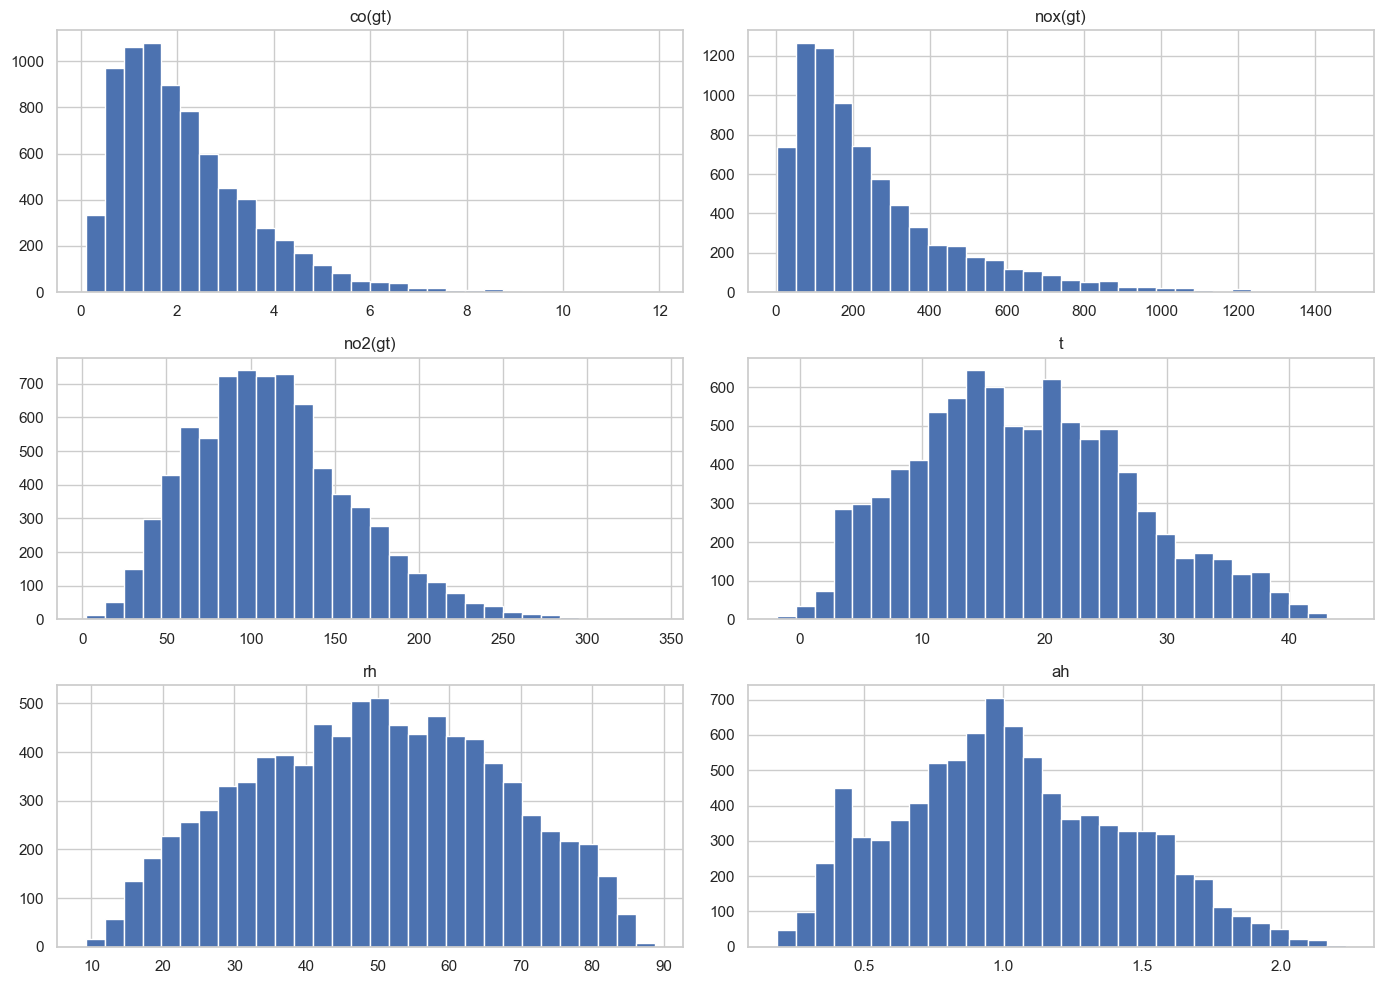

In [70]:
uci_clean[key_vars].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

Correlation Matrix

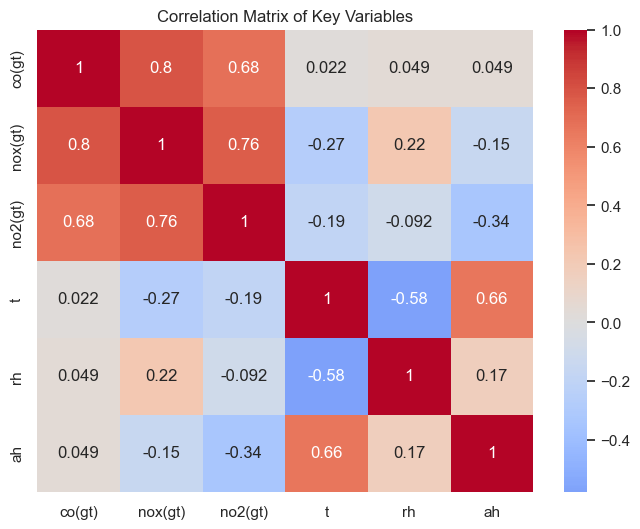

In [71]:
corr = uci_clean[key_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Variables")
plt.show()

Scatter Plot: NOx vs NO₂

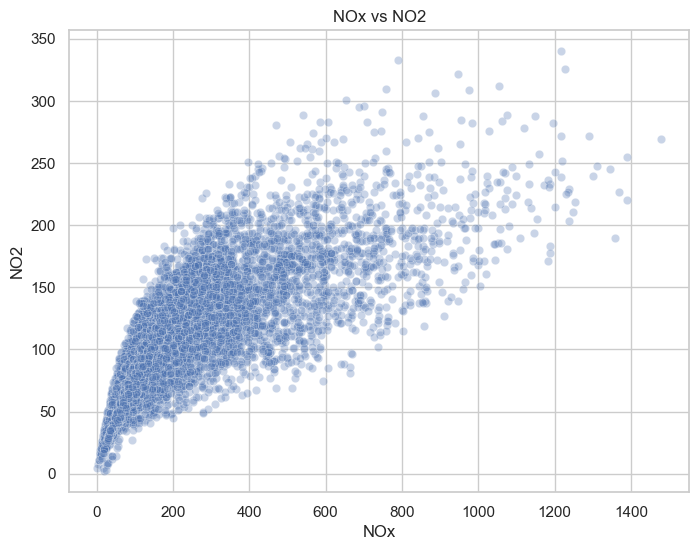

In [72]:

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=uci_clean,
    x="nox(gt)",
    y="no2(gt)",
    alpha=0.3
)


plt.title("NOx vs NO2")
plt.xlabel("NOx")
plt.ylabel("NO2")

plt.grid(True)
plt.show()

Monthly Aggregation Preview

In [73]:
monthly = uci_clean[key_vars].resample("ME").mean()
monthly.head()

,co(gt),nox(gt),no2(gt),t,rh,ah
datetime,,,,,,
2004-03-31,2.292073,143.493852,102.581967,14.390784,50.170784,0.789413
2004-04-30,2.303838,140.279835,96.880658,16.800722,50.708514,0.920774
2004-05-31,1.940034,122.132107,93.148829,20.281233,43.542329,0.957332
2004-06-30,1.900000,122.064715,94.084877,26.476540,39.850733,1.275380
2004-07-31,1.784946,126.754213,104.120956,29.419112,33.054240,1.242711


Monthly Trends

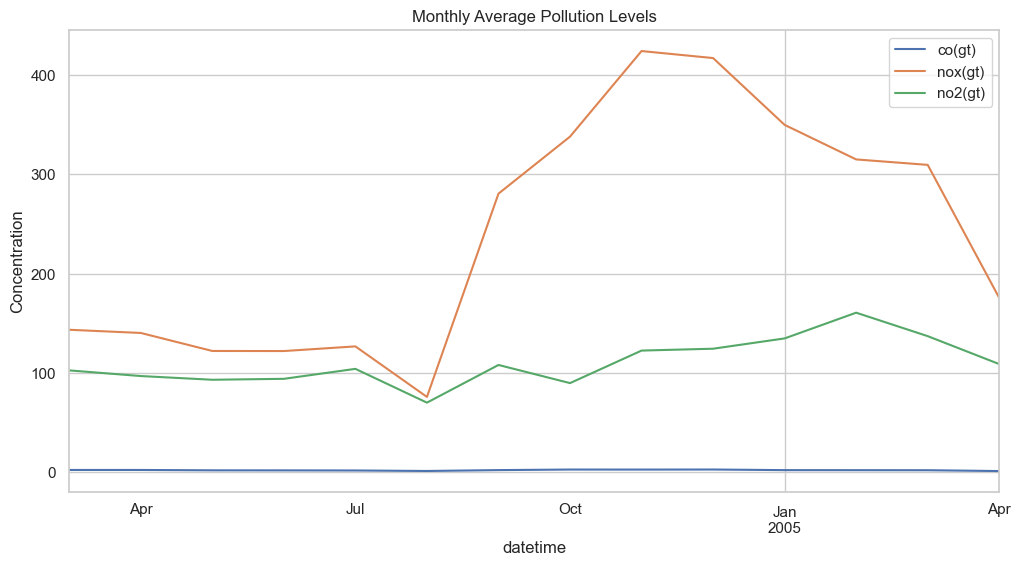

In [74]:
monthly[["co(gt)", "nox(gt)", "no2(gt)"]].plot(
    figsize=(12, 6)
)
plt.title("Monthly Average Pollution Levels")
plt.ylabel("Concentration")
plt.show()

## Regression Model: Traffic-Related Pollution Indicators

In this section, NO₂ concentration is modeled using traffic-related pollutants and meteorological variables.

The model is:

NO₂ = β₀ + β₁CO + β₂NOx + β₃T + β₄RH + β₅AH + ε

Model dataset shape: (6941, 6)
Model performance:


R2       0.679469
MAE     19.389568
RMSE    26.124476
dtype: float64

Regression coefficients:


,feature,coefficient
0,co(gt),8.584851
1,t,0.177946
2,nox(gt),0.125739
3,rh,-0.419559
4,ah,-33.291465


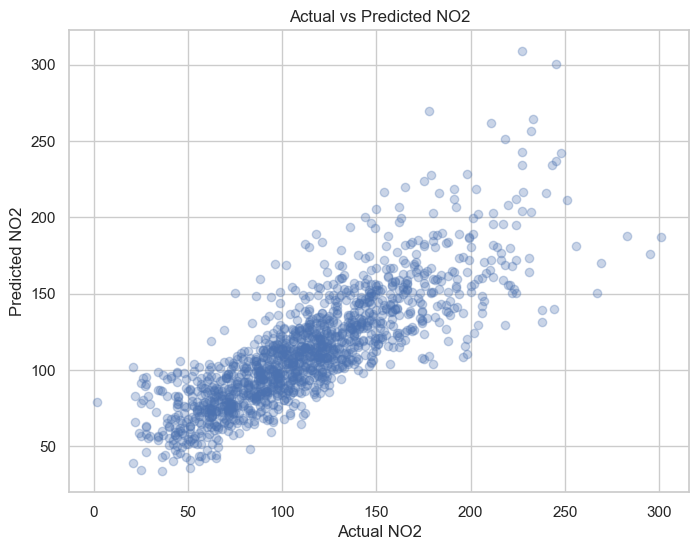

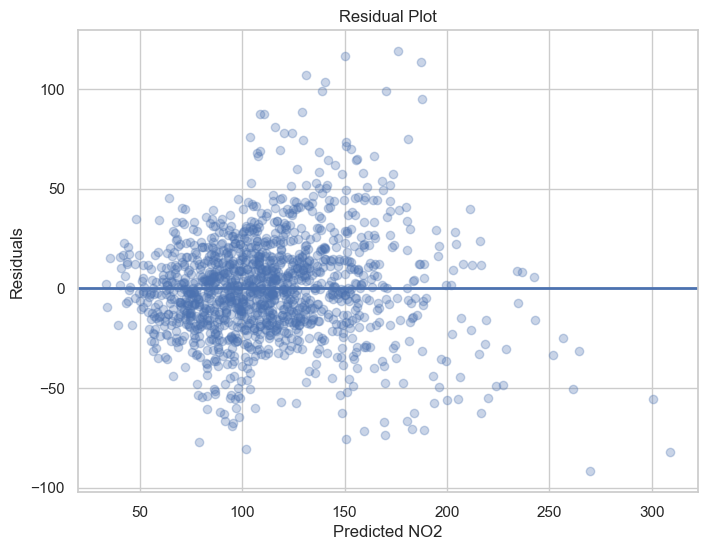

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

model_vars = [
    "no2(gt)",
    "co(gt)",
    "nox(gt)",
    "t",
    "rh",
    "ah",
]

model_df = uci_clean[model_vars].dropna()

print("Model dataset shape:", model_df.shape)

X = model_df[["co(gt)", "nox(gt)", "t", "rh", "ah"]]
y = model_df["no2(gt)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)


y_pred = reg_model.predict(X_test)

metrics = pd.Series({
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
})

print("Model performance:")
display(metrics)

coef_df = (
    pd.DataFrame({
        "feature": X.columns,
        "coefficient": reg_model.coef_,
    })
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

print("Regression coefficients:")
display(coef_df)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual NO2")
plt.ylabel("Predicted NO2")
plt.title("Actual vs Predicted NO2")
plt.grid(True)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, linewidth=2)
plt.xlabel("Predicted NO2")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

## Health Risk Analysis

This section analyzes the World Bank mortality indicator and connects air pollution exposure to public health outcomes.

In [76]:
wb_clean = wb_df.copy()

wb_clean = wb_clean.dropna(axis=1, how="all")

year_columns = [col for col in wb_clean.columns if col.isdigit()]

for col in year_columns:
    wb_clean[col] = pd.to_numeric(wb_clean[col], errors="coerce")

available_years = [
    col for col in year_columns
    if wb_clean[col].notna().sum() > 0
]

latest_year = max(available_years)

print("Latest available year column:", latest_year)

wb_latest = (
    wb_clean[["country_name", latest_year]]
    .rename(columns={latest_year: "mortality_rate"})
    .dropna()
)

print("Countries with available data:", len(wb_latest))

wb_latest.head()

Latest available year column: 2019
Countries with available data: 231


,country_name,mortality_rate
1,Africa Eastern and Southern,158.428356
2,Afghanistan,265.700000
3,Africa Western and Central,182.838948
4,Angola,142.800000
5,Albania,92.500000


In [77]:
top10 = wb_latest.sort_values(
    "mortality_rate",
    ascending=False
).head(10)

top10

,country_name,mortality_rate
34,Central African Republic,305.1
141,Lesotho,288.3
209,Solomon Islands,281.2
2,Afghanistan,265.7
258,Vanuatu,259.9
79,"Micronesia, Fed. Sts.",254.0
124,Kiribati,246.6
210,Sierra Leone,239.0
85,Guinea,238.0
213,"Somalia, Fed. Rep.",237.9


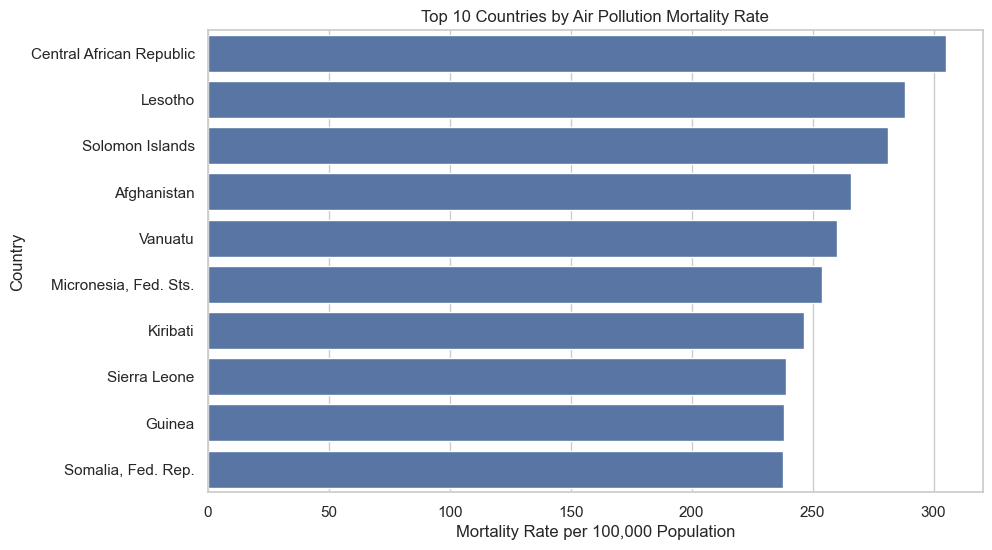

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x="mortality_rate",
    y="country_name"
)
plt.title("Top 10 Countries by Air Pollution Mortality Rate")
plt.xlabel("Mortality Rate per 100,000 Population")
plt.ylabel("Country")
plt.show()

In [79]:
import numpy as np

# Example epidemiological coefficient
beta = 0.0058

# Example increase in exposure
delta_exposure = 10  # µg/m³


def relative_risk(delta_exposure, beta):
    return np.exp(beta * delta_exposure)


def attributable_fraction(rr):
    return (rr - 1) / rr


rr = relative_risk(delta_exposure, beta)
af = attributable_fraction(rr)

print(f"Relative Risk (RR): {rr:.4f}")
print(f"Attributable Fraction (AF): {af:.4%}")

Relative Risk (RR): 1.0597
Attributable Fraction (AF): 5.6350%


The health-risk model is based on two standard epidemiological formulas.

Relative risk:
RR = exp(β × ΔExposure)

Attributable fraction:
AF = (RR − 1) / RR

These formulas estimate how much of a health outcome can be attributed to increased pollution exposure.

## Conclusions

This project combined two independent data sources to study the relationship between air pollution and public health.

The UCI Air Quality dataset was used to analyze the statistical relationships between traffic-related pollutants and meteorological variables. Exploratory analysis revealed strong positive correlations between NOx and NO2, as well as substantial seasonal variation.

A multiple linear regression model demonstrated that traffic-related indicators and weather conditions explain a large proportion of the variability in NO2 concentration.

The World Bank mortality dataset provided country-level evidence that air pollution is associated with substantial health burden worldwide.

Together, these analyses illustrate how environmental measurements can be connected to population-level health indicators using statistical and epidemiological methods.

## Limitations and Future Work

Several limitations should be acknowledged.

1. The two datasets are independent and operate at different spatial and temporal scales.
2. The UCI dataset represents measurements from a single urban monitoring station.
3. The World Bank dataset provides country-level annual indicators rather than local observations.
4. The analysis demonstrates statistical association rather than strict causality.

Future work may include:
- direct integration of city-level health datasets,
- non-linear and machine learning models,
- causal inference methods,
- scenario-based policy simulations.

## References

1. UCI Machine Learning Repository. Air Quality Dataset.
2. World Bank Open Data. Indicator SH.STA.AIRP.P5.
3. World Health Organization. AirQ+ methodology.
4. European Environment Agency. Air pollution and health assessments.
5. Scikit-learn documentation.
6. Pandas documentation.
7. Matplotlib and Seaborn documentation.